In [2]:
import irsdk
ir = irsdk.IRSDK()
ir.startup()

True

In [11]:
import csv
import time

# List of variables to record
vars_to_record = [
    'Lat',
    'Lon',
    'Speed',         # m/s
    'Gear',
    'RPM',
    'Throttle',
    'Brake',
    'Lap',
    'FuelLevel',
    'AirTemp'
]

data = []
start_time = time.time()
duration = 140  # seconds
while time.time() - start_time < duration:
    row = []
    for var in vars_to_record:
        value = ir[var]
        if var == 'Speed':
            value = value * 3.6  # Convert m/s to km/h
        row.append(value)
    data.append(row)
    time.sleep(0.1)

with open('data/iracing_vars.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Lat','Lon','peed_kmh', 'Gear', 'RPM', 'Throttle', 'Brake', 'Lap', 'FuelLevel_l', 'AirTemp_C'])
    writer.writerows(data)

print('Saved iracing_vars.csv with selected telemetry variables.')

Saved iracing_vars.csv with selected telemetry variables.


In [12]:
import csv

with open('data/iracing_vars.csv', 'r') as file:
    reader = csv.reader(file)
    header = next(reader)
    lat_idx = header.index('Lat')
    lon_idx = header.index('Lon')
    for row in reader:
        print(f"Lat: {row[lat_idx]}, Lon: {row[lon_idx]}")

Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 
Lat: , Lon: 

In [14]:
import pandas as pd

# Read CSV and save as pandas DataFrame
df = pd.read_csv('data/iracing_vars.csv')
print(df.head())

   Lat  Lon  peed_kmh  Gear         RPM  Throttle  Brake  Lap  FuelLevel_l  \
0  NaN  NaN  0.000323     0  875.186401       0.0    1.0    3    23.809439   
1  NaN  NaN  0.000118     0  875.131836       0.0    1.0    3    23.809420   
2  NaN  NaN  0.000297     0  875.088684       0.0    1.0    3    23.809401   
3  NaN  NaN  0.000620     0  875.058228       0.0    1.0    3    23.809381   
4  NaN  NaN  0.000385     0  875.032837       0.0    1.0    3    23.809364   

   AirTemp_C  
0  24.889994  
1  24.890034  
2  24.890074  
3  24.890114  
4  24.890152  


In [20]:
#!python3

import irsdk

import pprint

ibt_file = "bmw_test.ibt"

ir_ibt   = irsdk.IBT()

ir_ibt.open(ibt_file)

#var_headers = ir_ibt.var_headers_names

#pprint.pprint(var_headers)

lap_data = ir_ibt.get_all('LapCompleted')

# pprint.pprint(lap_data)

idx = 0

lap = 1

fuel_level = 0

fuel_level_ref = 0

# position data is delayed they say
lap_time_idx_offset = 125

for record_item in lap_data:
    # print(record_item)
    
    if record_item != lap:
        lap = record_item
        
        lap_time_last = ir_ibt.get((idx + lap_time_idx_offset), 'LapLastLapTime')
        
        lap_time_best = ir_ibt.get((idx + lap_time_idx_offset), 'LapBestLapTime')
        
        fuel_level    = ir_ibt.get(idx, 'FuelLevel')
        
        fuel_use      = fuel_level_ref - fuel_level
        
        print(str(lap).ljust(4) +
              str(idx).ljust(8) +
              str("{:.3f}".format(round(lap_time_last, 3))).ljust(9) +
              str(round(lap_time_best, 3)).ljust(9) +
              str(round(fuel_level, 2)).ljust(7) +
              str(round(fuel_use, 2)))
        
        print(ir_ibt['Lat'])
        print(ir_ibt['Lon'])
        if fuel_level != fuel_level_ref:
            fuel_level_ref = fuel_level
    idx += 1



ir_ibt.close()


0   0       0.000    0.0      60.0   -60.0
42.59690081773093
-83.68592197752521
-1  1       0.000    0.0      60.0   0.0
42.59690081773093
-83.68592197752521
0   943     0.000    0.0      59.9   0.1
42.59690081773093
-83.68592197752521
1   11317   -1.000   -1.0     59.1   0.81
42.59690081773093
-83.68592197752521
2   19522   -1.000   -1.0     58.4   0.7
42.59690081773093
-83.68592197752521
3   22230   -1.000   -1.0     57.72  0.67
42.59690081773093
-83.68592197752521
0   23889   -1.000   -1.0     60.0   -2.28
42.59690081773093
-83.68592197752521
3   23890   -1.000   -1.0     60.0   0.0
42.59690081773093
-83.68592197752521
4   36578   -1.000   -1.0     59.57  0.43
42.59690081773093
-83.68592197752521
5   38544   32.764   32.764   58.89  0.68
42.59690081773093
-83.68592197752521
6   40149   26.752   26.752   58.35  0.54
42.59690081773093
-83.68592197752521
7   55600   257.521  26.752   57.69  0.66
42.59690081773093
-83.68592197752521
0   63088   257.521  26.752   60.0   -2.31
42.59690081

In [28]:
import pandas as pd

# Replace 'iracing_vars.csv' with your desired filename if needed
df = pd.read_csv('data/mazda_charllote2.csv',delimiter=',',header=8)
print(df.head())

C:\Users\PC\AppData\Local\Temp\ipykernel_18780\3534327285.py:4: DtypeWarning: Columns (0,1,3,4,6,7,8,9,10,11,13,14,15,16,17,18,20,21,22,26,27,28,29,30,31,32,33,34,35,36,38,41,46,47,48,49,52,53,54,55,56,59,61,62,63,64,65,66,67,68,69,70,71,73,74,76,77,78,79,80,81,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,104,106,107,109,111,112,113,115,116,117,118,119,121,125,126,128,129,130,132,133,134,135,136,138,140,141,142,144,145,147,149,150,151,153,155,158,159,160,161,162,164,166,168,177,179,180,181,182,184,185,188,189,190,195,196,197,198,199,200,201,202,203,204,205,206,207,209,210,211,212,213,214,215,216,217,218,219,220,222,223,225,226,228,235,237,238,240,241,244,245,246,247,248,249,250,251,252,253,254,255,256,257,259,260,261,262,263,264,266,267,268,274,276) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/mazda_charllote2.csv',delimiter=',',header=8)


   AirTemp AirDensity  LapBestNLapLap LFwearL      Alt  MemSoftPageFaultSec  \
0        C     kg/m^3             NaN       %        m                  NaN   
1  30.9971    1.14304             0.0     100  206.148                  0.0   
2  30.9971    1.14304             0.0     100  206.148                  0.0   
3  30.9971    1.14304             0.0     100  206.148                  0.0   
4  30.9971    1.14304             0.0     100  206.148                  0.0   

   LFtempM LFpressure RFodometer AirPressure  ... YawNorth  \
0        C        kPa          m          Pa  ...      rad   
1  36.9948    206.843          0      100341  ...  3.42191   
2  36.9946    206.843          0      100341  ...  3.42191   
3  36.9944    206.843          0      100341  ...  3.42191   
4  36.9942    206.843          0      100341  ...  3.42191   

  dcPitSpeedLimiterToggle  dcStarter dcToggleWindshieldWipers  \
0                     NaN        NaN                      NaN   
1                     

In [29]:
df_mod = df.copy()
header = df_mod.columns[:]
first_row = df_mod.iloc[0,:]
df_mod.columns = header + ' (' + first_row + ")" #concatenate header + first row
df_mod  = df_mod.iloc[1:] #drop first row
df_mod

,AirTemp (C),AirDensity (kg/m^3),NaN,LFwearL (%),Alt (m),NaN,LFtempM (C),LFpressure (kPa),RFodometer (m),AirPressure (Pa),...,YawNorth (rad),NaN,NaN,NaN,NaN,NaN,dpLFTireColdPress (Pa),NaN,dpRFTireColdPress (Pa),NaN
1,30.9971,1.14304,0.0,100,206.148,0.0,36.9948,206.843,0,100341,...,3.42191,0.0,0.0,0.0,0.0,0.0,206.843,0.0,206.843,0.0
2,30.9971,1.14304,0.0,100,206.148,0.0,36.9946,206.843,0,100341,...,3.42191,0.0,0.0,0.0,0.0,0.0,206.843,0.0,206.843,0.0
3,30.9971,1.14304,0.0,100,206.148,0.0,36.9944,206.843,0,100341,...,3.42191,0.0,0.0,0.0,0.0,0.0,206.843,0.0,206.843,0.0
4,30.9971,1.14304,0.0,100,206.148,0.0,36.9942,206.843,0,100341,...,3.42191,0.0,0.0,0.0,0.0,0.0,206.843,0.0,206.843,0.0
5,30.9971,1.14304,0.0,100,206.148,0.0,36.994,206.843,0,100341,...,3.42191,0.0,0.0,0.0,0.0,0.0,206.843,0.0,206.843,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217352,25.8781,0.952274,0.0,83.3333,171.707,0.0,29.7338,172.297,0,83613.5,...,2.85175,0.0,0.0,0.0,0.0,0.0,172.369,0.0,172.369,0.0
217353,20.7025,0.761819,0.0,66.6667,137.365,0.0,23.787,137.838,0,66890.8,...,2.2814,0.0,0.0,0.0,0.0,0.0,137.895,0.0,137.895,0.0
217354,15.5268,0.571365,0.0,50.0,103.024,0.0,17.8403,103.378,0,50168.1,...,1.71105,0.0,0.0,0.0,0.0,0.0,103.421,0.0,103.421,0.0
217355,10.3512,0.38091,0.0,33.3333,68.6827,0.0,11.8935,68.9189,0,33445.4,...,1.1407,0.0,0.0,0.0,0.0,0.0,68.9476,0.0,68.9476,0.0


In [30]:
print(df['Lat'])
print(df['Lon'])

0                      deg
1         35.3509476231754
2         35.3509476231754
3         35.3509476231754
4         35.3509476231754
                ...       
217352           29.459123
217353           23.567298
217354           17.675474
217355           11.783649
217356           35.350948
Name: Lat, Length: 217357, dtype: object
0                       deg
1         -80.6852088579158
2         -80.6852088579158
3         -80.6852088579158
4         -80.6852088579158
                ...        
217352           -67.237674
217353           -53.790139
217354           -40.342604
217355            -26.89507
217356           -80.685209
Name: Lon, Length: 217357, dtype: object


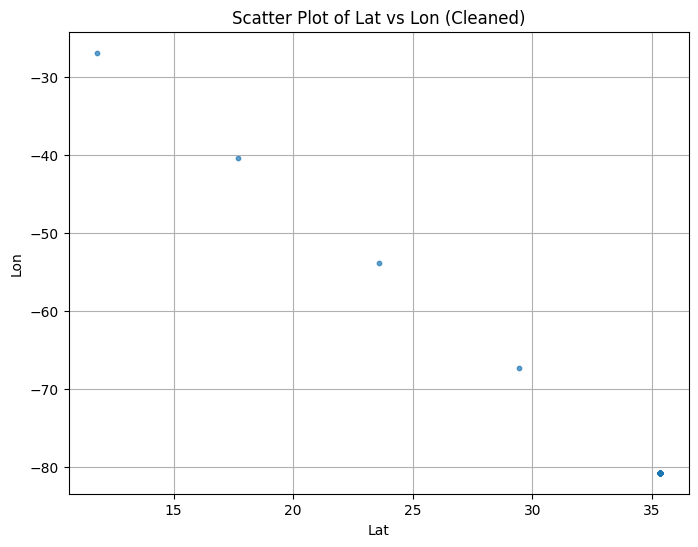

In [38]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(8,6))
plt.scatter(df['Lat'], df['Lon'], s=10, alpha=0.7)
plt.xlabel('Lat')
plt.ylabel('Lon')
plt.title('Scatter Plot of Lat vs Lon (Cleaned)')
plt.grid(True)
plt.show()

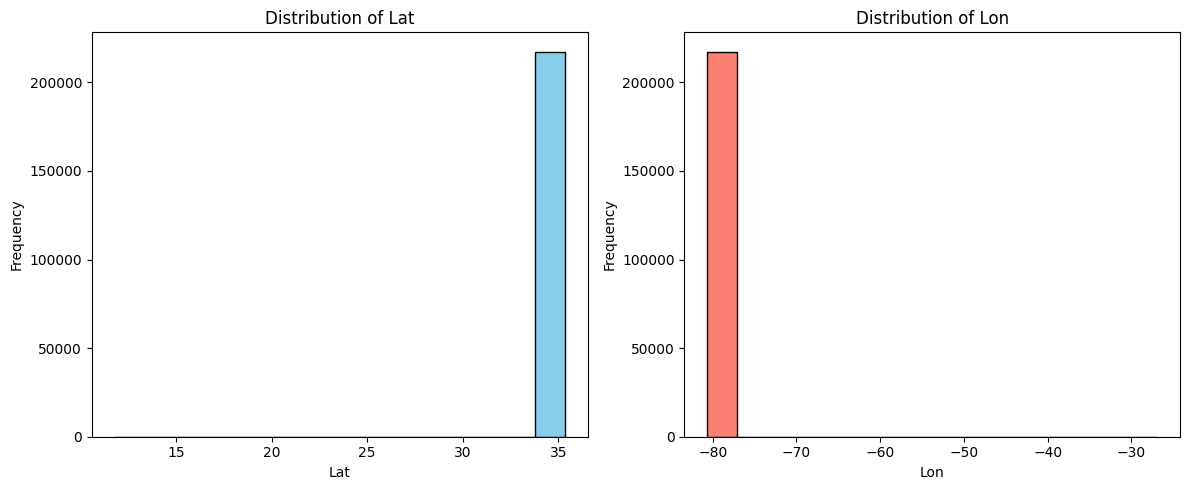

In [37]:
# Plot distribution of Lat and Lon
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['Lat'], bins=15, color='skyblue', edgecolor='black')
plt.xlabel('Lat')
plt.ylabel('Frequency')
plt.title('Distribution of Lat')
plt.subplot(1,2,2)
plt.hist(df['Lon'], bins=15, color='salmon', edgecolor='black')
plt.xlabel('Lon')
plt.ylabel('Frequency')
plt.title('Distribution of Lon')
plt.tight_layout()
plt.show()